In [2]:
!pip install joblib

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)


In [5]:
!pip install scikit-learn

  Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl (8.1 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- -----------

In [6]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

In [7]:
# Load Dataset
df_final_onehot = pd.read_csv('../../data/final/df_final_onehot.csv', keep_default_na = False)
df_final_onehot.shape

(278762, 80)

In [8]:
target = ['overall_status']
num_features = ['number_of_arms', 'log_enrollment', 'log_duration', 'intervention_count']
flag_features = ['has_dmc','has_expanded_access', 'is_fda_regulated_drug','is_fda_regulated_device', 'has_multiple_intervention_types', 'healthy_volunteers']
extra_feature = ['high_enroll_flag_975']
core_features = df_final_onehot.drop(columns = num_features + extra_feature + flag_features + target)
core_cols = [c for c in core_features if c not in ('nct_id')]

In [9]:
# Define features
X = df_final_onehot[num_features + core_cols + flag_features + extra_feature]
y = df_final_onehot['overall_status']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Preprocessing + Model Pipeline
# standardscaler: 로그변환을 했더라도 logistic regression은 경사하강법 계열의 알고리즘을 사용하므로 
# 수치형 변수의 스케일을 맞추는 것이 수렴 속도와 성능 면에서 매우 유리함
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', 'passthrough', core_cols + flag_features + extra_feature)
    ], remainder='drop'
)
# class_weight=balanced : overall_status 임상시험상태 데이터 불균형 심함. 이를 자동보정하도록
logreg = Pipeline(steps=[
    ('pre', preprocessor),
    ('clf', LogisticRegression(
        solver='lbfgs', penalty='l2', C=1,
        class_weight='balanced', max_iter=1000, random_state=42
    ))
])

In [10]:
# Train Model
logreg.fit(X_train, y_train)

# Predict with default threshold (0.5)
y_prob = logreg.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

# Evaluation metrics
print("=== Metrics at threshold 0.5 ===")
print("Accuracy :", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall   :", round(recall_score(y_test, y_pred), 3))
print("F1       :", round(f1_score(y_test, y_pred), 3))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 3))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

c:\Users\301-2\anaconda3\envs\ct_study\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


=== Metrics at threshold 0.5 ===
Accuracy : 0.811
Precision: 0.951
Recall   : 0.821
F1       : 0.881
ROC-AUC  : 0.86

Classification Report:
               precision    recall  f1-score   support

           0       0.41      0.75      0.53      8008
           1       0.95      0.82      0.88     47745

    accuracy                           0.81     55753
   macro avg       0.68      0.78      0.71     55753
weighted avg       0.87      0.81      0.83     55753



In [14]:
# Save classification report

import os

# 1. 저장할 경로 설정
save_dir = "../results/model_logreg/"

# 2. 폴더가 없으면 생성 (exist_ok=True는 이미 폴더가 있어도 에러를 내지 않게 합니다)
os.makedirs(save_dir, exist_ok=True)

# 3. 파일 저장
with open(os.path.join(save_dir, "logreg_classification_report_default.txt"), "w") as f:
    f.write(classification_report(y_test, y_pred))


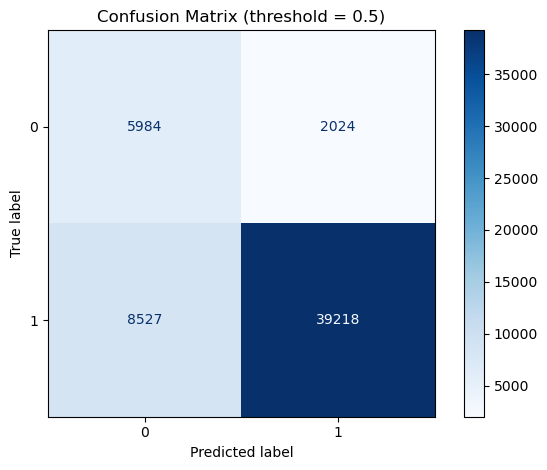

In [15]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix (threshold = 0.5)")
plt.tight_layout()
plt.savefig('../results/model_logreg/logreg_confusion_matrix_default.png', dpi = 200)
plt.show()

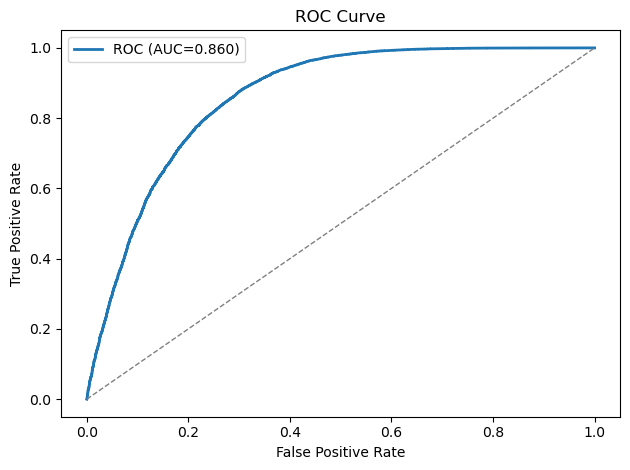

In [16]:
# ROC Curve
fpr, tpr, roc_th = roc_curve(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr, lw=2, label=f"ROC (AUC={roc_auc_score(y_test, y_prob):.3f})")
plt.plot([0, 1], [0, 1], "--", lw=1, color="grey")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve"); plt.legend()
plt.tight_layout()
plt.savefig('../results/model_logreg/logreg_roc_curve.png', dpi = 200)
plt.show()

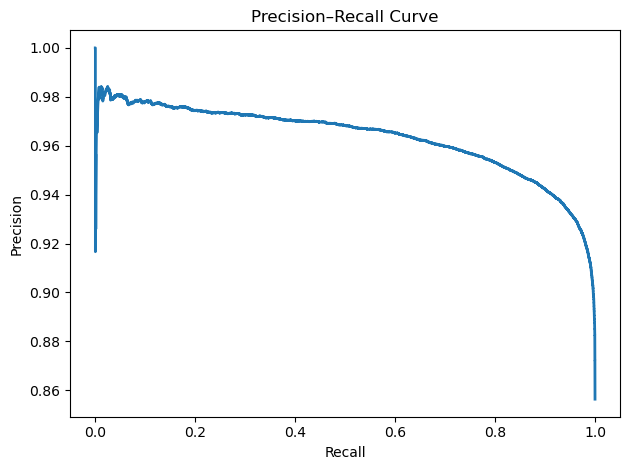

In [17]:
# Precision–Recall Curve
prec, rec, pr_th = precision_recall_curve(y_test, y_prob)
plt.figure()
plt.plot(rec, prec, lw=2)
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.tight_layout()
plt.savefig('../results/model_logreg/logreg_precision_recall_curve.png', dpi = 200)
plt.show()

In [18]:
# Optimal Threshold – Youden’s J 최적의 임계값 찾기
# roc커브에서 정확도는 극대화하고 오탐률은 최소화 하는 지점을 수학적으로 찾아냄
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_thr = roc_th[best_idx]

print(f"\nBest threshold by Youden J: {best_thr:.3f} (J={j_scores[best_idx]:.3f})")
y_pred_opt = (y_prob >= best_thr).astype(int)


Best threshold by Youden J: 0.422 (J=0.576)


In [19]:
print("\n=== Metrics at optimal threshold ===")
print("Accuracy :", round(accuracy_score(y_test, y_pred_opt), 3))
print("Precision:", round(precision_score(y_test, y_pred_opt), 3))
print("Recall   :", round(recall_score(y_test, y_pred_opt), 3))
print("F1       :", round(f1_score(y_test, y_pred_opt), 3))
print("\nClassification Report:\n", classification_report(y_test, y_pred_opt))


=== Metrics at optimal threshold ===
Accuracy : 0.854
Precision: 0.945
Recall   : 0.881
F1       : 0.912

Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.69      0.58      8008
           1       0.95      0.88      0.91     47745

    accuracy                           0.85     55753
   macro avg       0.72      0.79      0.75     55753
weighted avg       0.88      0.85      0.86     55753



In [20]:
# Save classification report
with open("../results/model_logreg/logreg_classification_report_optimal.txt", "w") as f:
    f.write(classification_report(y_test, y_pred_opt))

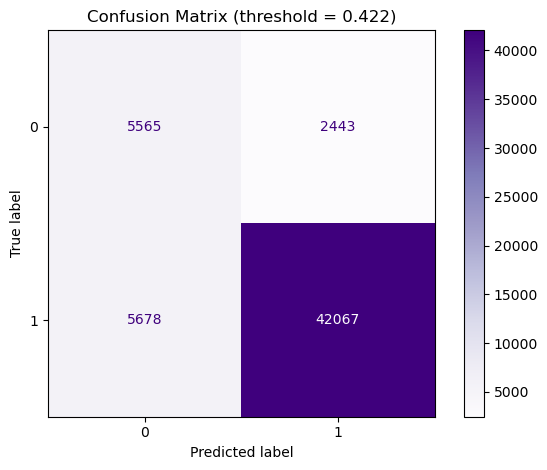

In [21]:
cm_opt = confusion_matrix(y_test, y_pred_opt)
ConfusionMatrixDisplay(cm_opt).plot(cmap="Purples", values_format="d")
plt.title(f"Confusion Matrix (threshold = {best_thr:.3f})")
plt.tight_layout()
plt.savefig('../results/model_logreg/logreg_confusion_matrix_optimal.png', dpi = 200)
plt.show()

In [23]:
# Save model and metrics
os.makedirs("../models", exist_ok=True)
joblib.dump(logreg, "../models/logreg_pipeline.pkl")

# Save feature columns
# 나중에 실제 서비스 환경에서 모델을 불러올때, 입력데이터의 컬럼 순서가 맞지 않으면 에러가 나거나 잘못 예측함
# 학습 당시의 컬럼 리스트를 저장해 두는것은 매우 훌륭한 엔지니어링 습관
joblib.dump(X.columns.tolist(), "../models/X_cols_logreg.pkl")

# Save metrics
# 임계값 조정 전후의 지표 모두 기록
metrics = {
    "Accuracy_0.5": round(accuracy_score(y_test, y_pred), 3),
    "Precision_0.5": round(precision_score(y_test, y_pred), 3),
    "Recall_0.5": round(recall_score(y_test, y_pred), 3),
    "F1_0.5": round(f1_score(y_test, y_pred), 3),
    "ROC_AUC": round(roc_auc_score(y_test, y_prob), 3),
    "Best_threshold": round(best_thr, 3),
    "Accuracy_opt": round(accuracy_score(y_test, y_pred_opt), 3),
    "Precision_opt": round(precision_score(y_test, y_pred_opt), 3),
    "Recall_opt": round(recall_score(y_test, y_pred_opt), 3),
    "F1_opt": round(f1_score(y_test, y_pred_opt), 3)
}

pd.DataFrame([metrics]).to_csv("../results/model_logreg/model_logreg_metrics.csv", index=False)

print("\n✅ Model, feature list, and metrics saved.")


✅ Model, feature list, and metrics saved.
